In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [6]:
df=pd.read_csv("/workspaces/backtesting/investment-portfolio-project/data/signal_data.csv", index_col=0, parse_dates=True)

# Calcular retornos diarios
df['Returns'] = df['close'].pct_change().fillna(0)

# Agregar columna de posición: 1 si y_pred == 1, 0 si y_pred == 0
df['Position'] = df['y_pred'].shift(1).fillna(0)

# Retorno de estrategia: solo ganamos si tenemos posición
df['Strategy_Returns'] = df['Position'] * df['Returns']


In [7]:
def sharpe_ratio(returns, risk_free_rate=0.0):
    excess_returns = returns - risk_free_rate
    return np.sqrt(252) * np.mean(excess_returns) / np.std(excess_returns)

def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

# Cumulative returns
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()
df['Cumulative_BuyHold'] = (1 + df['Returns']).cumprod()

# Sharpe
strategy_sharpe = sharpe_ratio(df['Strategy_Returns'])
buyhold_sharpe = sharpe_ratio(df['Returns'])

# Max drawdown
strategy_mdd = max_drawdown(df['Cumulative_Strategy'])
buyhold_mdd = max_drawdown(df['Cumulative_BuyHold'])

print("📊 Performance Metrics:")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")
print(f"Buy & Hold Sharpe Ratio: {buyhold_sharpe:.2f}")
print(f"Strategy Max Drawdown: {strategy_mdd:.2%}")
print(f"Buy & Hold Max Drawdown: {buyhold_mdd:.2%}")


📊 Performance Metrics:
Strategy Sharpe Ratio: 0.50
Buy & Hold Sharpe Ratio: 0.21
Strategy Max Drawdown: -30.29%
Buy & Hold Max Drawdown: -78.89%


/workspaces/backtesting/my_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


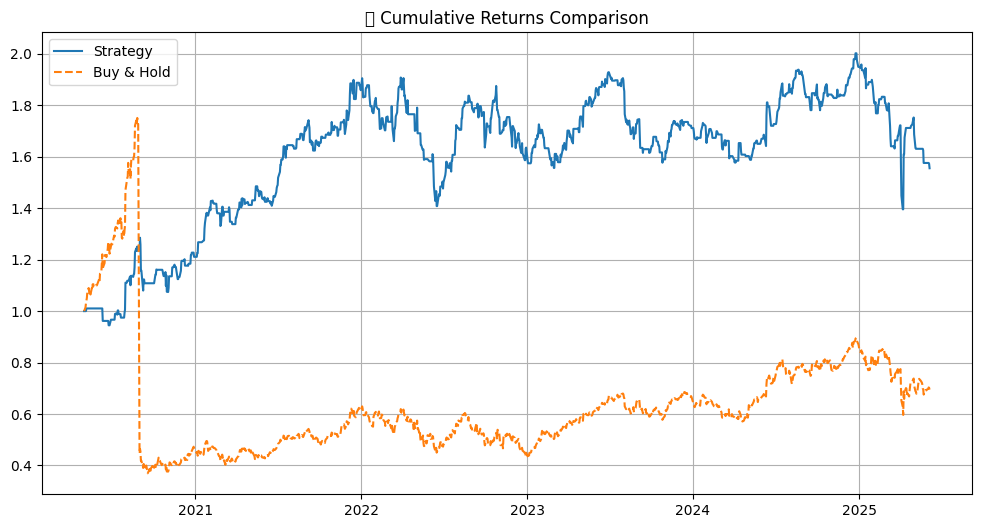

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df['Cumulative_Strategy'], label='Strategy')
plt.plot(df['Cumulative_BuyHold'], label='Buy & Hold', linestyle='--')
plt.title("📈 Cumulative Returns Comparison")
plt.legend()
plt.grid(True)
plt.show()
